### HRV COVID-19 EDA

Download data if not present:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path
import subprocess

repo_url = "https://github.com/Welltory/hrv-covid19.git"
repo_dir = Path("hrv-covid19")

if not repo_dir.exists():
    subprocess.run([
        "git", "clone",
        "--depth", "1",
        "--filter=blob:none",
        "--sparse",
        repo_url,
        str(repo_dir)
    ], check=True)

subprocess.run([
    "git", "-C", str(repo_dir),
    "sparse-checkout", "set", "data"
], check=True)

data_dir = repo_dir / "data"

print(f"Data downloaded to: {data_dir.resolve()}")
print("\nFiles:")
for path in data_dir.rglob("*"):
    if path.is_file():
        print(path)

Data downloaded to: /Users/vagiz/Desktop/desktop_vagiz/duke/aipi510/aipi510-fall26/week4/hrv-covid19/data

Files:
hrv-covid19/data/scales_description.csv
hrv-covid19/data/participants.csv
hrv-covid19/data/wearables.csv
hrv-covid19/data/blood_pressure.csv
hrv-covid19/data/surveys.csv
hrv-covid19/data/heart_rate.csv
hrv-covid19/data/weather.csv
hrv-covid19/data/hrv_measurements.csv
hrv-covid19/data/sleep.csv


## Data Structure

Before diving into features of the tables, we need to establish the relationships of the database - the data sources obviously are not independent.

```
                         participants
                     PK: user_code
                           │
          ┌────────────────┼──────────────────────────────┐
          │                │                              │
          ▼                ▼                              ▼
 hrv_measurements    blood_pressure                  heart_rate
 PK: rr_code         candidate PK:                   candidate PK:
 FK: user_code       (user_code,                     (user_code,
                      measurement_datetime)            daytime)
          │
          │
          ├───────────────────────────────────────────────┐
          │                                               │
          ▼                                               ▼
      wearables                 sleep                  weather
 candidate PK:             candidate PK:           candidate PK:
 (user_code, day)          (user_code, day)        (user_code, day)
 FK: user_code             FK: user_code           FK: user_code


                        surveys
               candidate PK:
               (user_code, scale, created_at)
               FK: user_code
               FK: (scale, value)
                       │
                       ▼
              scales_description
              PK: (scale, value)
```

In [3]:
import pandas as pd
from pathlib import Path

data_dir = Path("hrv-covid19/data")

tables = {
    path.stem: pd.read_csv(path)
    for path in data_dir.glob("*.csv")
}

PRIMARY_KEYS = {
    "participants": ["user_code"],
    "hrv_measurements": ["rr_code"],
    "blood_pressure": ["user_code", "measurement_datetime"],
    "heart_rate": ["user_code", "datetime"],
    "wearables": ["user_code", "day"],
    "sleep": ["user_code", "day"],
    "weather": ["user_code", "day"],
    "surveys": ["user_code", "scale", "created_at"],
    "scales_description": ["Scale", "Description"],
}

for table_name, pk in PRIMARY_KEYS.items():
    df = tables[table_name]

    n_rows = len(df)
    n_unique = df[pk].drop_duplicates().shape[0]
    n_duplicates = n_rows - n_unique

    print(
        f"{table_name:20s} "
        f"PK={str(pk):45s} "
        f"rows={n_rows:8,d} "
        f"duplicates={n_duplicates:6,d}"
    )

participants         PK=['user_code']                                 rows=     185 duplicates=     0
hrv_measurements     PK=['rr_code']                                   rows=   3,245 duplicates=     0
blood_pressure       PK=['user_code', 'measurement_datetime']         rows=     721 duplicates=     0
heart_rate           PK=['user_code', 'datetime']                     rows= 523,783 duplicates= 7,330
wearables            PK=['user_code', 'day']                          rows=   3,098 duplicates=     0
sleep                PK=['user_code', 'day']                          rows=     425 duplicates=    38
weather              PK=['user_code', 'day']                          rows=   1,717 duplicates=     0
surveys              PK=['user_code', 'scale', 'created_at']          rows=   2,259 duplicates=    24
scales_description   PK=['Scale', 'Description']                      rows=     148 duplicates=    74


We see that initial guess on what PK looks like is good for:

1. `participants`
2. `hrv_measures`
3. `blood_pressure`
4. `wearables`
5. `weather`

whereas other tables have $\leq 10\%$ of duplicates (`scales_description` has a tone of duplicate drows so we forget about it).

## Heart Rate & Sleep

We decided to join `heart_rate` with `sleep` and see if heart rate and sleep duration are correlated.

In [4]:
hr = tables["heart_rate"].copy()
sleep = tables["sleep"].copy()

sleep_users = set(sleep["user_code"])
hr_users = set(hr["user_code"])

print("Users with sleep:", len(sleep_users))
print("Users with heart rate:", len(hr_users))
print("Users with both:", len(sleep_users & hr_users))

print(
    "Sleep rows belonging to overlapping users:",
    sleep["user_code"].isin(hr_users).sum()
)

Users with sleep: 10
Users with heart rate: 79
Users with both: 10
Sleep rows belonging to overlapping users: 425


In [5]:
hr["datetime"] = pd.to_datetime(hr["datetime"])
sleep["sleep_begin"] = pd.to_datetime(sleep["sleep_begin"])

sleep = sleep.reset_index(drop=True)
sleep["sleep_id"] = sleep.index

availability = []

for _, row in sleep.iterrows():
    start = row["sleep_begin"] - pd.Timedelta(hours=24)
    end = row["sleep_begin"]

    mask = (
        (hr["user_code"] == row["user_code"])
        & (hr["datetime"] >= start)
        & (hr["datetime"] < end)
    )

    user_hr = hr.loc[mask]

    availability.append({
        "sleep_id": row["sleep_id"],
        "user_code": row["user_code"],
        "sleep_begin": row["sleep_begin"],
        "sleep_duration": row["sleep_duration"],
        "n_hr_previous_24h": len(user_hr),
    })

availability = pd.DataFrame(availability)

print("Total sleep episodes:", len(availability))

print(
    "Episodes with any HR in previous 24h:",
    (availability["n_hr_previous_24h"] > 0).sum()
)

print(
    "Episodes with >= 10 HR measurements:",
    (availability["n_hr_previous_24h"] >= 10).sum()
)

print(
    "Episodes with >= 50 HR measurements:",
    (availability["n_hr_previous_24h"] >= 50).sum()
)

display(
    availability["n_hr_previous_24h"].describe()
)

Total sleep episodes: 425
Episodes with any HR in previous 24h: 356
Episodes with >= 10 HR measurements: 325
Episodes with >= 50 HR measurements: 321


count      425.000000
mean       438.644706
std       1107.017817
min          0.000000
25%         57.000000
50%        259.000000
75%        317.000000
max      11406.000000
Name: n_hr_previous_24h, dtype: float64

In [6]:
sleep_coverage = pd.DataFrame({
    "non_missing": sleep.notna().sum(),
    "coverage_pct": sleep.notna().mean() * 100,
    "n_unique": sleep.nunique(dropna=True),
}).sort_values("coverage_pct", ascending=False)

display(sleep_coverage)

,non_missing,coverage_pct,n_unique
user_code,425,100.000000,10
day,425,100.000000,154
sleep_begin,425,100.000000,424
sleep_end,425,100.000000,425
sleep_duration,425,100.000000,334
sleep_id,425,100.000000,425
sleep_light_duration,27,6.352941,22
pulse_min,15,3.529412,11
pulse_max,15,3.529412,11
pulse_average,15,3.529412,14


## Research Question

We saw that `sleep_duration` is present in all $426$ sleep episodes. We also see that about $321 / 426 \approx 75\%$ of sleep episodes have at least $50$ heart rate measurements on the day of the episode. An interesting research question could be:

> **Research Question**: Is heart-rate behavior before a sleep episode associated with how long the person subsequently sleeps?

We will come up with a single temporal statistic of HR during the day and explore its correlation with sleep duration.

> **What value this Research Question brings?** At the momen person falls asleep, we could estimate their sleep duration and build a software logic around that.

## Target: Sleep Duration

In [7]:
REQUIRED_HR_MEASUREMENTS = 50

In [8]:
hr = tables["heart_rate"].copy()
sleep = tables["sleep"].copy()

hr["datetime"] = pd.to_datetime(hr["datetime"])
sleep["sleep_begin"] = pd.to_datetime(sleep["sleep_begin"])
sleep["sleep_end"] = pd.to_datetime(sleep["sleep_end"])

# One unique identifier per sleep episode
sleep = sleep.reset_index(drop=True)
sleep["sleep_id"] = sleep.index

# Sleep duration appears to be stored in seconds
sleep["sleep_duration_hours"] = sleep["sleep_duration"] / 3600

rows = []

for _, s in sleep.iterrows():
    start = s["sleep_begin"] - pd.Timedelta(hours=24)
    end = s["sleep_begin"]

    h = hr[
        (hr["user_code"] == s["user_code"])
        & (hr["datetime"] >= start)
        & (hr["datetime"] < end)
    ]

    rows.append({
        "sleep_id": s["sleep_id"],
        "user_code": s["user_code"],
        "sleep_begin": s["sleep_begin"],
        "sleep_duration_hours": s["sleep_duration_hours"],

        # Just descriptive summaries for now
        "n_hr": len(h),
        "mean_hr_24h": h["heart_rate"].mean(),
        "median_hr_24h": h["heart_rate"].median(),
        "std_hr_24h": h["heart_rate"].std(),
    })

analysis = pd.DataFrame(rows)

analysis.head()

,sleep_id,user_code,sleep_begin,sleep_duration_hours,n_hr,mean_hr_24h,median_hr_24h,std_hr_24h
0,0,0d297d2410,2019-12-31 07:50:32,0.913889,0,NaN,NaN,NaN
1,1,0d297d2410,2020-01-01 04:13:41,5.522500,8,90.750000,92.0,1.908627
2,2,0d297d2410,2020-01-02 02:14:52,5.852222,100,75.870000,77.0,14.591166
3,3,0d297d2410,2020-01-03 00:10:00,8.586111,150,75.513333,76.5,14.285082
4,4,0d297d2410,2020-01-04 01:27:25,7.415278,123,77.170732,78.0,15.905308


We see missing values - these samples are not meaningful for us, that is why we need to drop them. We could use per-user statistics to fill them, but for the first iteration we prefer dropping them.

In [9]:
eda = analysis[
    analysis["n_hr"] >= REQUIRED_HR_MEASUREMENTS
].copy()

print("EDA sample size:", len(eda))
print("Users:", eda["user_code"].nunique())

EDA sample size: 321
Users: 6


In [10]:
eda["sleep_duration_hours"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)

count    321.000000
mean       7.150331
std        2.018334
min        0.750000
1%         1.350556
5%         3.550556
25%        6.026667
50%        7.317778
75%        8.500000
95%       10.166667
99%       10.733333
max       11.083333
Name: sleep_duration_hours, dtype: float64

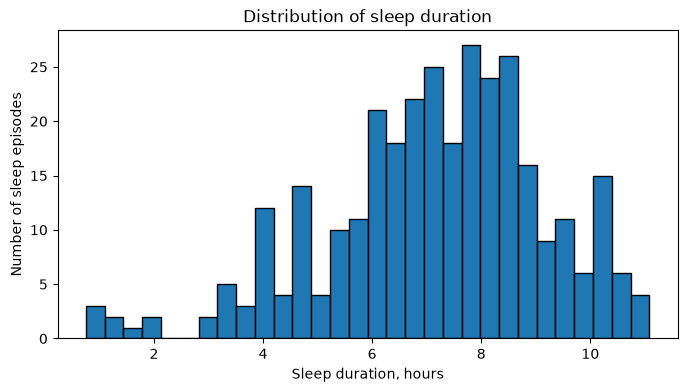

In [11]:
plt.figure(figsize=(8, 4))

plt.hist(
    eda["sleep_duration_hours"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Sleep duration, hours")
plt.ylabel("Number of sleep episodes")
plt.title("Distribution of sleep duration")

plt.show()

The target data is complete and accurate, measured in seconds. We see a lot of missing data for other sleep components, but this target specifically is integrate and consistent. We also see a Gaussian distribution, which is expected.

## Mean HR vs Sleep Duration

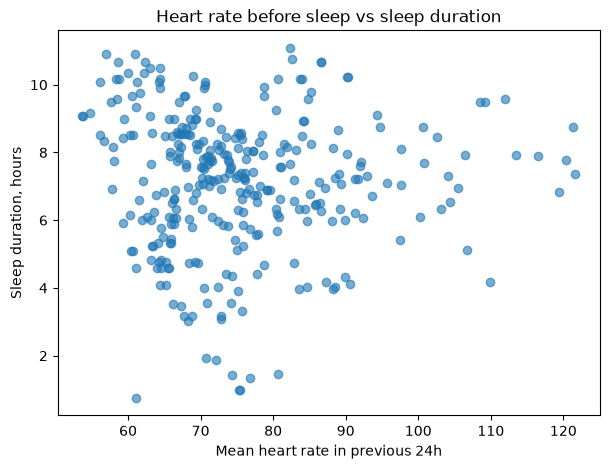

In [12]:
plt.figure(figsize=(7, 5))

plt.scatter(
    eda["mean_hr_24h"],
    eda["sleep_duration_hours"],
    alpha=0.6
)

plt.xlabel("Mean heart rate in previous 24h")
plt.ylabel("Sleep duration, hours")
plt.title("Heart rate before sleep vs sleep duration")

plt.show()

In [13]:
eda[
    ["mean_hr_24h", "median_hr_24h", "std_hr_24h", "sleep_duration_hours"]
].corr()

,mean_hr_24h,median_hr_24h,std_hr_24h,sleep_duration_hours
mean_hr_24h,1.000000,0.975113,0.605254,-0.024427
median_hr_24h,0.975113,1.000000,0.535597,-0.020550
std_hr_24h,0.605254,0.535597,1.000000,0.139181
sleep_duration_hours,-0.024427,-0.020550,0.139181,1.000000


**Result**: No meaningful linear correlation of mean HR during the day and sleep duration for particular $6$ users.

Even within each user, there is not trend:

In [14]:
per_user_corr = (
    eda.groupby("user_code")
    .apply(
        lambda x: pd.Series({
            "n": len(x),
            "mean_hr_corr": x["mean_hr_24h"].corr(
                x["sleep_duration_hours"]
            ),
            "std_hr_corr": x["std_hr_24h"].corr(
                x["sleep_duration_hours"]
            ),
        }),
        include_groups=False,
    )
    .sort_values("n", ascending=False)
)

per_user_corr

,n,mean_hr_corr,std_hr_corr
user_code,,,
6be5033971,106.0,-0.098050,-0.089783
35c7355282,102.0,-0.028821,-0.062113
a1c2e6b2eb,57.0,0.321644,0.382884
4985083f4d,36.0,-0.160821,0.266873
0d297d2410,14.0,0.167375,0.484128
fcf3ea75b0,6.0,0.511819,-0.696794


## Change in HR vs Sleep Duration

Let's engineer something more sophisticated:

$$HR_\text{Drop} = median(HR_\text{day}) - median(HR_\text{before sleep})$$

This features tries to exploit the dynamics in HR before sleep. I take only sleep episodes with enough measurements per window. Also, the dynamics of HR before bed probably reflect the amount of stress a person experiences, and that should directly affect the sleep quality & duration (deep phase, for example).

In [15]:
MIN_HR_MEASUREMENTS_PER_WINDOW = 10

In [16]:
hr = tables["heart_rate"].copy()
sleep = tables["sleep"].copy()

hr["datetime"] = pd.to_datetime(hr["datetime"])
sleep["sleep_begin"] = pd.to_datetime(sleep["sleep_begin"])

sleep = sleep.reset_index(drop=True)
sleep["sleep_id"] = sleep.index
sleep["sleep_duration_hours"] = sleep["sleep_duration"] / 3600

rows = []

for _, s in sleep.iterrows():
    bedtime = s["sleep_begin"]

    user_hr = hr[hr["user_code"] == s["user_code"]]

    # 8h to 4h before sleep
    earlier_hr = user_hr[
        (user_hr["datetime"] >= bedtime - pd.Timedelta(hours=8))
        & (user_hr["datetime"] < bedtime - pd.Timedelta(hours=2))
    ]

    # Final 4h before sleep
    presleep_hr = user_hr[
        (user_hr["datetime"] >= bedtime - pd.Timedelta(hours=2))
        & (user_hr["datetime"] < bedtime)
    ]

    rows.append({
        "sleep_id": s["sleep_id"],
        "user_code": s["user_code"],
        "sleep_begin": bedtime,
        "sleep_duration_hours": s["sleep_duration_hours"],

        "n_hr_earlier": len(earlier_hr),
        "n_hr_presleep": len(presleep_hr),

        "median_hr_earlier": earlier_hr["heart_rate"].median(),
        "median_hr_presleep": presleep_hr["heart_rate"].median(),
    })

features = pd.DataFrame(rows)

features["hr_drop_before_sleep"] = (
    features["median_hr_earlier"]
    - features["median_hr_presleep"]
)

In [17]:
print("Total sleep episodes:", len(features))

print(
    "Episodes with both windows:",
    features[
        ["median_hr_earlier", "median_hr_presleep"]
    ].notna().all(axis=1).sum()
)

display(
    features[
        ["n_hr_earlier", "n_hr_presleep"]
    ].describe(
        percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]
    )
)

Total sleep episodes: 425
Episodes with both windows: 306


,n_hr_earlier,n_hr_presleep
count,425.000000,425.000000
mean,175.230588,19.647059
std,890.259867,16.421846
min,0.000000,0.000000
10%,0.000000,0.000000
25%,3.000000,0.000000
50%,49.000000,25.000000
75%,75.000000,25.000000
90%,104.000000,28.000000
max,8897.000000,73.000000


In [18]:
eda_dynamic = features[
    (features["n_hr_earlier"] >= MIN_HR_MEASUREMENTS_PER_WINDOW)
    & (features["n_hr_presleep"] >= MIN_HR_MEASUREMENTS_PER_WINDOW)
].dropna(
    subset=["hr_drop_before_sleep", "sleep_duration_hours"]
)

print("Usable episodes:", len(eda_dynamic))
print("Users:", eda_dynamic["user_code"].nunique())

eda_dynamic[
    ["hr_drop_before_sleep", "sleep_duration_hours"]
].corr()

Usable episodes: 277
Users: 6


,hr_drop_before_sleep,sleep_duration_hours
hr_drop_before_sleep,1.000000,0.186833
sleep_duration_hours,0.186833,1.000000


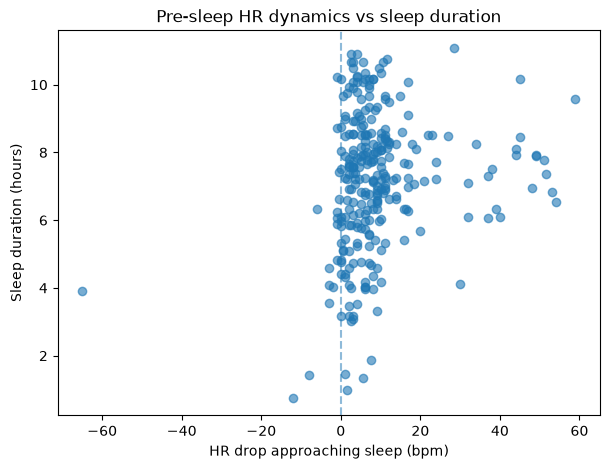

In [19]:
plt.figure(figsize=(7, 5))

plt.scatter(
    eda_dynamic["hr_drop_before_sleep"],
    eda_dynamic["sleep_duration_hours"],
    alpha=0.6,
)

plt.axvline(0, linestyle="--", alpha=0.5)

plt.xlabel("HR drop approaching sleep (bpm)")
plt.ylabel("Sleep duration (hours)")
plt.title("Pre-sleep HR dynamics vs sleep duration")

plt.show()

We see several outliers - basically a single outlier on the left of the graph. All other outliers are filtered out by `MIN_HR_MEASUREMENTS_PER_WINDOW` requirement.

**Result**: Weak positive correlation ($\approx 0.19$) between the engineered feature and sleep duration, better than just average HR ($\approx 0.02$ correlation).